# Breast Cancer Classification Using Support Vector Machines
**IT5514 - Applied Machine Learning — Assignment 01**  
**Name:** Sithum Wickramanayaka  
**Index number:** 269214N  
**Batch 19**

This notebook compares Linear and RBF SVMs for predicting breast tumor diagnosis. Malignant is the positive class (1) and benign is 0. Run all cells in order in Jupyter. The dataset is bundled with scikit-learn, so no separate data downloaded.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
OUT = Path('results')
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_rows', 40)
print('Python:', sys.version.split()[0], '| scikit-learn:', sklearn.__version__)


Python: 3.12.14 | scikit-learn: 1.9.1


## 1. Data preparation
### Dataset source and diagnosis encoding
Source: [scikit-learn breast cancer dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html), derived from the [UCI Breast Cancer Wisconsin Diagnostic dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic). UCI attribution: Wolberg, W., Mangasarian, O., Street, N., and Street, W. (1995), DOI: [10.24432/C5DW2B](https://doi.org/10.24432/C5DW2B).

Observations: 569 | Features: 30
Target: diagnosis; 0 = benign; 1 = malignant


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


Variable data types


,dtype
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


Summary statistics for all numerical features


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


,Diagnosis,Count,Percentage
0,Benign (0),357,62.74
1,Malignant (1),212,37.26


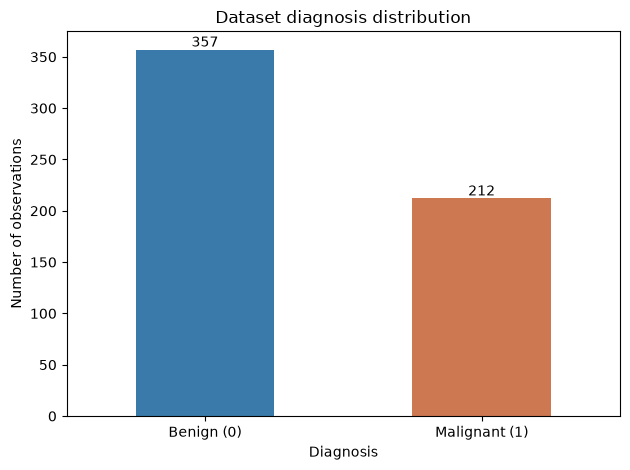

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = (data.target == 0).astype('int64').rename('diagnosis')
df = X.assign(diagnosis=y)
assert list(data.target_names) == ['malignant', 'benign']
print('Observations:', len(X), '| Features:', X.shape[1])
print('Target: diagnosis; 0 = benign; 1 = malignant')
display(df.head())
print('Variable data types')
display(df.dtypes.rename('dtype').to_frame())
print('Summary statistics for all numerical features')
display(X.describe().T)
class_counts = y.value_counts().sort_index()
class_table = pd.DataFrame({'Diagnosis': ['Benign (0)', 'Malignant (1)'],
                            'Count': class_counts.values,
                            'Percentage': (class_counts.values / len(y) * 100).round(2)})
display(class_table)
ax = class_table.plot.bar(x='Diagnosis', y='Count', legend=False, color=['#397aab','#ce7851'], rot=0)
ax.set(title='Dataset diagnosis distribution', ylabel='Number of observations', xlabel='Diagnosis')
for i, v in enumerate(class_counts): ax.text(i, v+3, str(v), ha='center')
plt.tight_layout(); plt.show()


In [3]:
print('Missing values per variable')
display(df.isna().sum().rename('Missing count').to_frame())
print('Total missing values:', int(df.isna().sum().sum()))
print('Duplicate feature rows:', int(X.duplicated().sum()))
assert not df.isna().any().any()
assert np.isfinite(X.to_numpy()).all()
# The bundled feature matrix contains no ID column, all 30 columns are diagnostic measurements.
# No missing values exist, so no imputation is needed. Keep extreme measurements:
# unusual tumor characteristics may be meaningful, rather than erroneous outliers.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
split_table = pd.DataFrame({
    'Training': [len(y_train), (y_train==0).sum(), (y_train==1).sum()],
    'Testing': [len(y_test), (y_test==0).sum(), (y_test==1).sum()]},
    index=['Total', 'Benign (0)', 'Malignant (1)'])
display(split_table)
assert set(X_train.index).isdisjoint(X_test.index)


Missing values per variable


,Missing count
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


Total missing values: 0
Duplicate feature rows: 0


,Training,Testing
Total,455,114
Benign (0),285,72
Malignant (1),170,42


### Why scaling matters
SVMs depend on dot products and, for RBF, distances. Features such as area have much larger numeric ranges than smoothness and could dominate the model without scaling. StandardScaler subtracts each training-feature mean and divides by its training standard deviation. The same fitted transformation is applied to testing data. A pipeline fits scaling separately within every cross-validation fold, preventing validation or test information from leaking into training.

## 2. SVM model development
A linear kernel learns a hyperplane in the standardized feature space. It is useful when classes are approximately linearly separable and offers a simpler decision function. The RBF kernel uses similarity exp(−gamma × squared distance) and can represent curved boundaries, making it useful when relationships are nonlinear. Its flexibility needs careful tuning to limit overfitting.

C controls the penalty for training errors: larger C tolerates fewer violations but can overfit. RBF gamma controls how locally each observation influences the boundary. We tune both kernels using identical stratified five-fold training partitions. Mean validation ROC-AUC is the predeclared selection criterion because it evaluates ranking across thresholds. The test set is reserved for final reporting, it does not choose parameters or the kernel.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grids = {
    'Linear SVM': {'svc__C': [0.01, 0.1, 1, 10, 100]},
    'RBF SVM': {'svc__C': [0.01, 0.1, 1, 10, 100],
                'svc__gamma': ['scale', 0.001, 0.01, 0.1, 1]}}
searches = {}
for name, kernel in [('Linear SVM', 'linear'), ('RBF SVM', 'rbf')]:
    pipeline = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel=kernel))])
    search = GridSearchCV(pipeline, grids[name], scoring='roc_auc', cv=cv,
                          n_jobs=1, refit=True, error_score='raise')
    search.fit(X_train, y_train)
    searches[name] = search
cv_table = pd.DataFrame([{'Model': name, 'Best parameters': str(s.best_params_),
    'Mean CV ROC-AUC': s.best_score_,
    'CV standard deviation': s.cv_results_['std_test_score'][s.best_index_]}
    for name, s in searches.items()]).set_index('Model')
display(cv_table)
selected_name = max(searches, key=lambda name: searches[name].best_score_)
print('Selected by training CV:', selected_name)
# Every best estimator has now been refitted on all training observations.
scaler = searches[selected_name].best_estimator_.named_steps['scaler']
scaled_train = scaler.transform(X_train)
print('Largest absolute scaled training mean:', np.abs(scaled_train.mean(axis=0)).max())
print('Training standard deviation range:', scaled_train.std(axis=0).min(), scaled_train.std(axis=0).max())
assert np.allclose(scaler.mean_, X_train.mean(axis=0))
assert np.allclose(scaled_train.mean(axis=0), 0, atol=1e-10)


,Best parameters,Mean CV ROC-AUC,CV standard deviation
Model,,,
Linear SVM,{'svc__C': 0.1},0.994427,0.006083
RBF SVM,"{'svc__C': 100, 'svc__gamma': 0.001}",0.995975,0.004310


Selected by training CV: RBF SVM
Largest absolute scaled training mean: 7.242070191401021e-16
Training standard deviation range: 0.9999999999999998 1.0


## 3. Model evaluation
Accuracy measures the fraction of all diagnoses classified correctly. Precision is TP/(TP+FP), recall is TP/(TP+FN), and F1 is their harmonic mean. Precision, recall and F1 below refer to **malignant (1)**. ROC-AUC uses continuous decision scores, not predicted class labels. Positive scores favor malignancy, scores are not probabilities. Class predictions use the default SVC decision threshold.

In [5]:
predictions, scores, rows = {}, {}, {}
for name, search in searches.items():
    predictions[name] = search.predict(X_test)
    scores[name] = search.decision_function(X_test)
    pred = predictions[name]
    rows[name] = {'Accuracy': accuracy_score(y_test, pred),
                  'Precision': precision_score(y_test, pred, pos_label=1, zero_division=0),
                  'Recall': recall_score(y_test, pred, pos_label=1),
                  'F1-Score': f1_score(y_test, pred, pos_label=1),
                  'ROC-AUC': roc_auc_score(y_test, scores[name])}
comparison = pd.DataFrame(rows)
comparison.index.name = 'Evaluation metric'
display(comparison.round(4))
comparison.to_csv(OUT / 'model_comparison.csv')


,Linear SVM,RBF SVM
Evaluation metric,,
Accuracy,0.9825,0.9737
Precision,1.0000,1.0000
Recall,0.9524,0.9286
F1-Score,0.9756,0.9630
ROC-AUC,0.9964,0.9957


## 4. Confusion matrix and ROC analysis
The selected model is the best model by training cross-validation ROC-AUC. Rows of the matrix show actual diagnoses and columns show predictions. A false negative is a malignant tumor incorrectly predicted benign,a false positive is a benign tumor incorrectly predicted malignant.

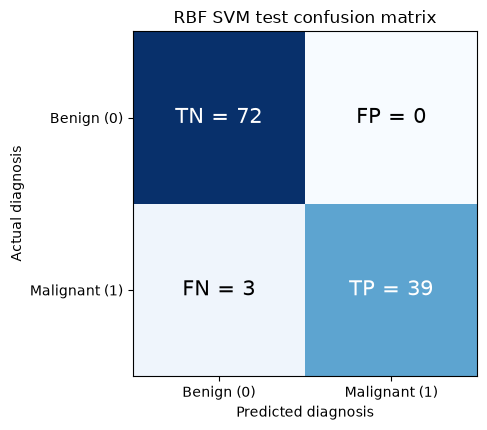

TN=72: benign correctly identified; FP=0: benign predicted malignant
FN=3: malignant predicted benign; TP=39: malignant correctly identified


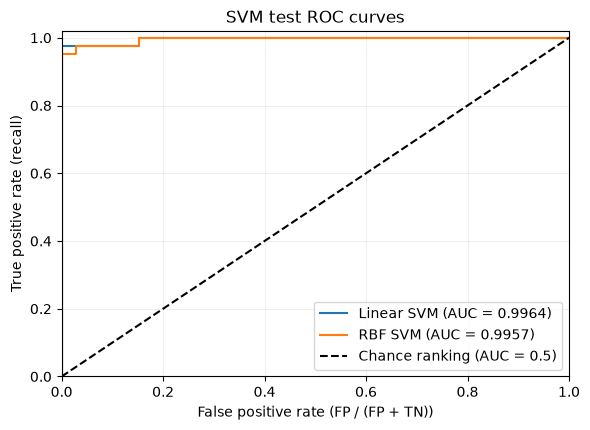

In [6]:
cm = confusion_matrix(y_test, predictions[selected_name], labels=[0, 1])
tn, fp, fn, tp = map(int, cm.ravel())
fig, ax = plt.subplots(figsize=(6, 4.4))
ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max())
for i, j, label in [(0,0,'TN'), (0,1,'FP'), (1,0,'FN'), (1,1,'TP')]:
    ax.text(j, i, f'{label} = {cm[i,j]}', ha='center', va='center',
            fontsize=15, color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set(xticks=[0,1], yticks=[0,1], xticklabels=['Benign (0)','Malignant (1)'],
       yticklabels=['Benign (0)','Malignant (1)'], xlabel='Predicted diagnosis',
       ylabel='Actual diagnosis', title=f'{selected_name} test confusion matrix')
fig.tight_layout(); fig.savefig(OUT/'confusion_matrix.png', dpi=180); plt.show()
print(f'TN={tn}: benign correctly identified; FP={fp}: benign predicted malignant')
print(f'FN={fn}: malignant predicted benign; TP={tp}: malignant correctly identified')
fig, ax = plt.subplots(figsize=(6, 4.4))
for name in searches:
    fpr, tpr, _ = roc_curve(y_test, scores[name], pos_label=1)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {rows[name]['ROC-AUC']:.4f})")
ax.plot([0,1],[0,1], 'k--', label='Chance ranking (AUC = 0.5)')
ax.set(xlim=(0,1), ylim=(0,1.02), xlabel='False positive rate (FP / (FP + TN))',
       ylabel='True positive rate (recall)', title='SVM test ROC curves')
ax.legend(loc='lower right'); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(OUT/'roc_curve.png', dpi=180); plt.show()


### Best observed test model
Linear SVM has the higher test accuracy, recall, F1 and ROC-AUC, with equal precision. Its confusion matrix is also shown to cover the best observed test performer. This retrospective comparison does not replace the training-CV selection or trigger further tuning.

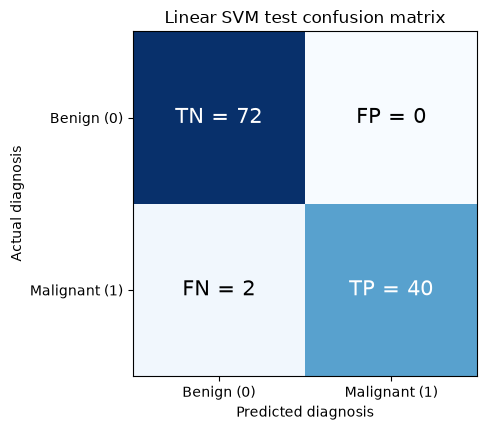

Linear SVM: TN=72, FP=0, FN=2, TP=40. It missed one fewer malignant case than RBF.


In [7]:
linear_cm = confusion_matrix(y_test, predictions['Linear SVM'], labels=[0,1])
fig, ax = plt.subplots(figsize=(6, 4.4))
ax.imshow(linear_cm, cmap='Blues', vmin=0, vmax=linear_cm.max())
for i,j,label in [(0,0,'TN'),(0,1,'FP'),(1,0,'FN'),(1,1,'TP')]:
    ax.text(j,i,f'{label} = {linear_cm[i,j]}',ha='center',va='center',fontsize=15,
            color='white' if linear_cm[i,j]>linear_cm.max()/2 else 'black')
ax.set(xticks=[0,1],yticks=[0,1],xticklabels=['Benign (0)','Malignant (1)'],
       yticklabels=['Benign (0)','Malignant (1)'],xlabel='Predicted diagnosis',
       ylabel='Actual diagnosis',title='Linear SVM test confusion matrix')
fig.tight_layout(); fig.savefig(OUT/'linear_confusion_matrix.png',dpi=180); plt.show()
print('Linear SVM: TN=72, FP=0, FN=2, TP=40. It missed one fewer malignant case than RBF.')
assert linear_cm.tolist() == [[72,0],[2,40]]


In [8]:
m = rows[selected_name]
interpretation = (
    f"The {selected_name} achieved the highest mean training CV ROC-AUC "
    f"({searches[selected_name].best_score_:.4f}). On the 114 test observations, "
    f"its accuracy was {m['Accuracy']:.2%}, precision {m['Precision']:.2%}, "
    f"malignant recall {m['Recall']:.2%}, F1 {m['F1-Score']:.4f}, and AUC {m['ROC-AUC']:.4f}. "
    f"It correctly identified {tp} of {tp+fn} malignant cases and {tn} of {tn+fp} benign cases; "
    f"{fn} malignant cases were missed and {fp} benign cases were flagged as malignant. "
    "The ROC curve describes the trade-off between detecting malignancies and false alarms as "
    "the score threshold changes. An AUC close to 1 indicates strong ranking of malignant above "
    "benign cases, but does not mean every diagnosis is correct or that scores are calibrated probabilities.")
display(Markdown(interpretation))
auc_gap = rows['RBF SVM']['ROC-AUC'] - rows['Linear SVM']['ROC-AUC']
f1_gap = rows['RBF SVM']['F1-Score'] - rows['Linear SVM']['F1-Score']
display(Markdown(f'RBF minus Linear test ROC-AUC is {auc_gap:+.4f}; the F1 difference is '
                 f'{f1_gap:+.4f}. Kernel performance depends on the metric and threshold, '
                 'so the comparison table should be considered alongside missed malignant cases. '
                 'The held-out results do not change the model selected from training CV.'))
summary = {'selected': selected_name, 'metrics': rows,
           'cv': {k: {'mean_auc': v.best_score_, 'params': v.best_params_} for k,v in searches.items()},
           'confusion': {'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}, 'interpretation': interpretation,
           'sklearn_version': sklearn.__version__}
(OUT/'summary.json').write_text(json.dumps(summary, indent=2))
assert cm.sum() == len(y_test) == 114
assert len(y_train) == 455
assert tp + fn == int(y_test.sum())
print('All consistency checks passed.')


The RBF SVM achieved the highest mean training CV ROC-AUC (0.9960). On the 114 test observations, its accuracy was 97.37%, precision 100.00%, malignant recall 92.86%, F1 0.9630, and AUC 0.9957. It correctly identified 39 of 42 malignant cases and 72 of 72 benign cases; 3 malignant cases were missed and 0 benign cases were flagged as malignant. The ROC curve describes the trade-off between detecting malignancies and false alarms as the score threshold changes. An AUC close to 1 indicates strong ranking of malignant above benign cases, but does not mean every diagnosis is correct or that scores are calibrated probabilities.

RBF minus Linear test ROC-AUC is -0.0007; the F1 difference is -0.0126. Kernel performance depends on the metric and threshold, so the comparison table should be considered alongside missed malignant cases. The held-out results do not change the model selected from training CV.

All consistency checks passed.


## 5. Supplementary analysis Decision boundaries
These plots illustrate how Linear and RBF SVM boundaries differ using **mean radius** and **mean texture**, following the two-feature approach in the supplied lab templates. Separate demonstration models are fitted only to these two features from the original training partition. Each model standardizes its inputs inside a pipeline, axes remain in the original measurement units.

For a controlled illustration, both models use C = 1 and the RBF model uses gamma = 'scale'. These settings are fixed rather than tuned for this illustration. Shading shows the predicted diagnosis, the solid black contour marks the decision boundary (score = 0), and dotted contours mark scores −1 and +1. Points show training diagnoses. The dotted contours are score levels, not confidence intervals or probabilities.

**These are separate two-feature demonstration models, not a projection of the evaluated 30-feature models.** The original split, tuned models, predictions and evaluation results remain the basis of the assignment conclusions.

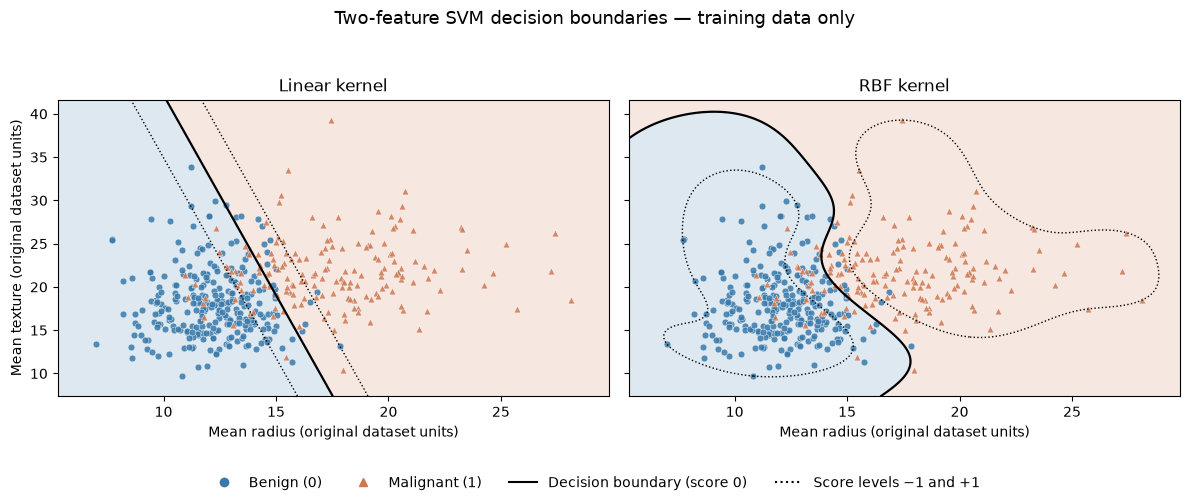

In [9]:
# Fit independent two-feature models for visualization; preserve the main estimators.
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

boundary_features = ['mean radius', 'mean texture']
X_boundary = X_train.loc[:, boundary_features]
boundary_models = {}
limits = []
for feature in boundary_features:
    low, high = X_boundary[feature].min(), X_boundary[feature].max()
    padding = 0.08 * (high - low)
    limits.append((low - padding, high + padding))
xx, yy = np.meshgrid(np.linspace(*limits[0], 350),
                     np.linspace(*limits[1], 350))
grid = pd.DataFrame(np.column_stack([xx.ravel(), yy.ravel()]),
                    columns=boundary_features)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
colors = ['#397aab', '#ce7851']
for ax, kernel, title in zip(axes, ['linear', 'rbf'], ['Linear kernel', 'RBF kernel']):
    demonstration = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel=kernel, C=1.0, gamma='scale'))])
    demonstration.fit(X_boundary, y_train)
    boundary_models[kernel] = demonstration
    surface = demonstration.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, (surface >= 0).astype(int),
                levels=[-0.5, 0.5, 1.5], cmap=ListedColormap(colors), alpha=0.17)
    ax.contour(xx, yy, surface, levels=[-1, 0, 1], colors='black',
               linestyles=[':', '-', ':'], linewidths=[1, 1.6, 1])
    for label, marker in [(0, 'o'), (1, '^')]:
        mask = y_train == label
        ax.scatter(X_boundary.loc[mask, boundary_features[0]],
                   X_boundary.loc[mask, boundary_features[1]],
                   c=colors[label], marker=marker, s=24,
                   edgecolors='white', linewidths=0.35, alpha=0.85)
    ax.set(title=title, xlabel='Mean radius (original dataset units)',
           xlim=limits[0], ylim=limits[1])
axes[0].set_ylabel('Mean texture (original dataset units)')
legend_items = [
    Line2D([], [], marker='o', linestyle='None', color=colors[0], label='Benign (0)'),
    Line2D([], [], marker='^', linestyle='None', color=colors[1], label='Malignant (1)'),
    Line2D([], [], color='black', label='Decision boundary (score 0)'),
    Line2D([], [], color='black', linestyle=':', label='Score levels −1 and +1')]
fig.suptitle('Two-feature SVM decision boundaries — training data only', fontsize=13)
fig.legend(handles=legend_items, loc='lower center', ncol=4, frameon=False)
fig.tight_layout(rect=[0, 0.09, 1, 0.94])
fig.savefig(OUT / 'decision_boundaries.png', dpi=180, bbox_inches='tight')
plt.show()

# Verify that visualization uses only training rows and two diagnostic features.
assert X_boundary.index.equals(X_train.index)
assert set(X_boundary.index).isdisjoint(X_test.index)
assert all(model.n_features_in_ == 2 for model in boundary_models.values())
assert all(search.best_estimator_.n_features_in_ == 30 for search in searches.values())


The linear boundary is straight in this two-feature view, whereas the RBF boundary can curve as the feature values change. Overlap between the colored training points shows why these two measurements alone cannot perfectly separate the diagnoses. Curvature does not by itself imply better generalization: the main comparison still uses the held-out results from the 30-feature models. Shaded regions away from observed points are model extrapolations and should be interpreted cautiously.

## 6. Conclusion and limitations
Both kernels are evaluated on the same untouched test split after training-only parameter selection. Strong discrimination on this dataset supports the usefulness of standardized SVM features, but a single small split cannot establish statistical superiority or performance on new hospitals or populations. False negatives matter because they miss malignancy. Threshold adjustment could change recall and precision, but must be chosen using training validation data, with independent evaluation afterward. This assignment does not establish clinical readiness.
